In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [5]:
df = pd.read_csv('data.csv')

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

FIRST 5 ROWS
          isbn13      isbn10           title subtitle  \
0  9780002005883  0002005883          Gilead      NaN   
1  9780002261982  0002261987    Spider's Web  A Novel   
2  9780006163831  0006163831    The One Tree      NaN   
3  9780006178736  0006178731  Rage of angels      NaN   
4  9780006280897  0006280897  The Four Loves      NaN   

                           authors                     categories  \
0               Marilynne Robinson                        Fiction   
1  Charles Osborne;Agatha Christie  Detective and mystery stories   
2             Stephen R. Donaldson               American fiction   
3                   Sidney Sheldon                        Fiction   
4              Clive Staples Lewis                 Christian life   

                                           thumbnail  \
0  http://books.google.com/books/content?id=KQZCP...   
1  http://books.google.com/books/content?id=gA5GP...   
2  http://books.google.com/books/content?id=OmQaw...   
3  ht

In [6]:
df = df.dropna()

In [7]:
# Input Features
X = df[['published_year', 'num_pages', 'ratings_count']]

# Target Output
y = df['average_rating']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [10]:
predictions = model.predict(X_test)

In [12]:
ae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("\nMean Absolute Error:")
print(ae)

print("\nR2 Score:")
print(r2)


Mean Absolute Error:
0.237921052631579

R2 Score:
-0.17606041320469923


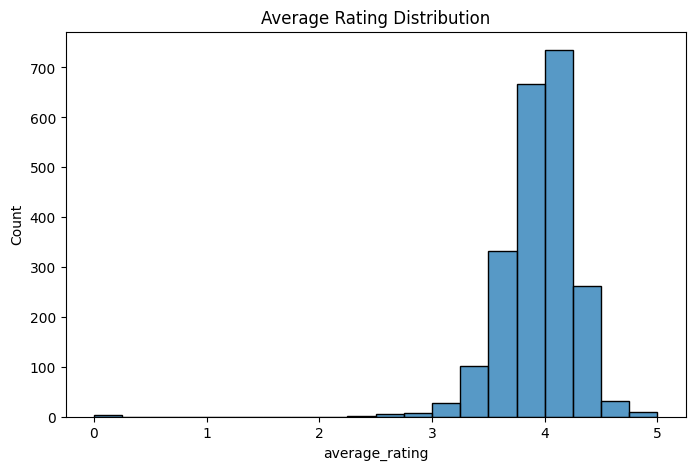

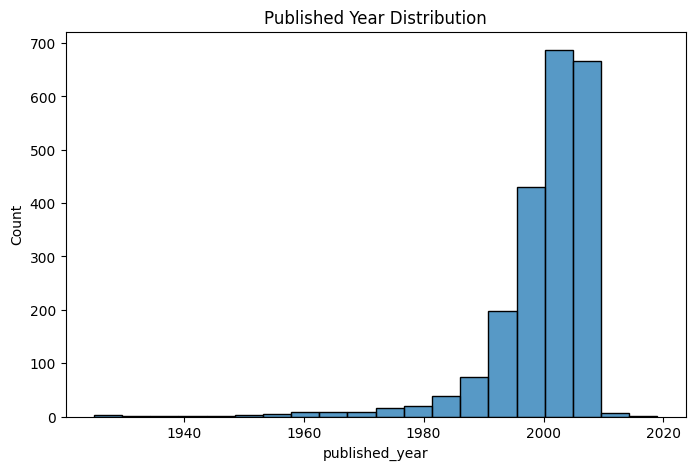

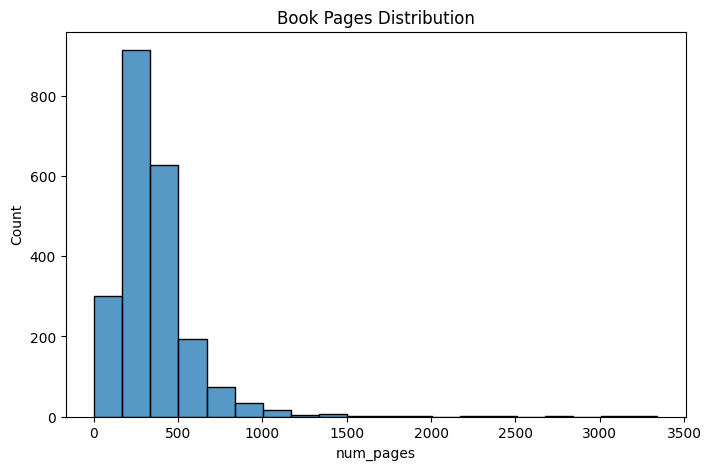

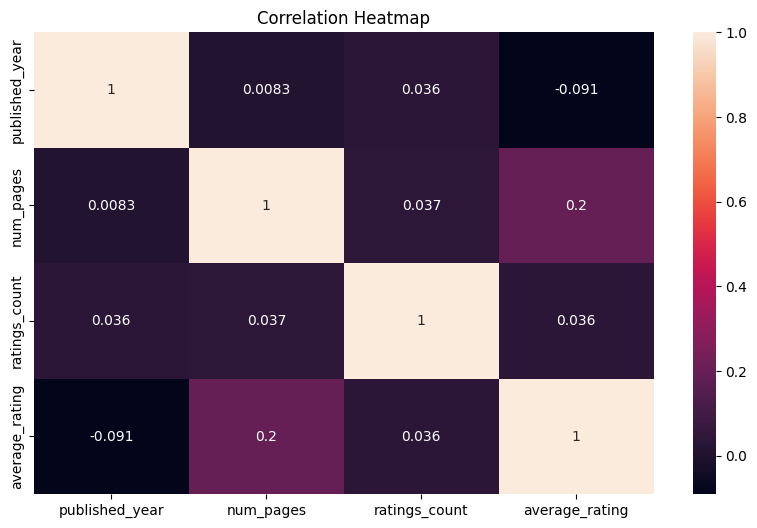

In [13]:
# Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['average_rating'], bins=20)
plt.title("Average Rating Distribution")
plt.show()

# Published Year Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['published_year'], bins=20)
plt.title("Published Year Distribution")
plt.show()

# Number of Pages Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['num_pages'], bins=20)
plt.title("Book Pages Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['published_year', 'num_pages', 'ratings_count', 'average_rating']].corr(),
            annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Example:
# published_year = 2010
# num_pages = 300
# ratings_count = 5000

sample = pd.DataFrame(
    [[2010, 300, 5000]],
    columns=X.columns
)

prediction = model.predict(sample)

print("\nPredicted Book Rating:")
print(prediction)



Predicted Book Rating:
[3.8345]
